In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Cargar y limpiar los datos de tu results.csv
# Asegúrate de que la ruta apunte correctamente a donde tienes tu CSV guardado
ruta_csv = '../models/entrenamiento_script_estable/results.csv' 
df = pd.read_csv(ruta_csv)

# Limpiar los nombres de las columnas (YOLO suele dejar espacios en blanco molestos)
df.columns = df.columns.str.strip()

# 2. Crear una figura con dos subgráficas (Pérdida y Precisión)
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Evolución del Error (Loss)', 'Evolución de la Precisión (mAP50)'))

# --- GRÁFICA 1: Pérdida (Train vs Val) ---
# Curva de entrenamiento
fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['train/box_loss'], name="Error de Entrenamiento", line=dict(color='blue')),
    row=1, col=1
)
# Curva de validación
fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['val/box_loss'], name="Error de Validación", line=dict(color='cyan', dash='dot')),
    row=1, col=1
)

# --- GRÁFICA 2: Precisión (mAP50) ---
fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['metrics/mAP50(B)'], name="Precisión (mAP50)", line=dict(color='green', width=3)),
    row=1, col=2
)

# 3. Diseño y formato profesional
fig.update_layout(
    title_text="Análisis de Rendimiento del Modelo YOLOv8-ADAS",
    title_x=0.5, # Centrar el título
    template="plotly_white", # Fondo blanco limpio
    hovermode="x unified", # Muestra todos los valores al pasar el ratón sobre un punto
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
)

# Etiquetas de los ejes
fig.update_xaxes(title_text="Épocas", row=1, col=1)
fig.update_xaxes(title_text="Épocas", row=1, col=2)
fig.update_yaxes(title_text="Pérdida (Box Loss)", row=1, col=1)
fig.update_yaxes(title_text="Precisión Media", row=1, col=2)

# 4. Mostrar la gráfica interactiva en Jupyter
fig.show()

# 5. Opcional: Guardarla como una página web interactiva (.html) para compartir
# fig.write_html("reporte_interactivo.html")

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Cargar y limpiar los datos de tu results.csv
ruta_csv = '../models/entrenamiento_script_estable/results.csv' 
df = pd.read_csv(ruta_csv)
df.columns = df.columns.str.strip()

# ============================================================
# FIGURA 1: Evolución del Error (Box Loss)
# ============================================================
fig_loss = go.Figure()

# --- Curva de entrenamiento (Rojo Vibrante) ---
fig_loss.add_trace(
    go.Scatter(x=df['epoch'], y=df['train/box_loss'], 
               name="Entrenamiento", line=dict(color='#E63946', width=3))
)

# --- Curva de validación (Naranja Oro) ---
fig_loss.add_trace(
    go.Scatter(x=df['epoch'], y=df['val/box_loss'], 
               name="Validación", line=dict(color='#F4A261', width=3, dash='dot'))
)

# Diseño solucionando el empalme
fig_loss.update_layout(
    title_text="Análisis de Pérdida (Box Loss) - YOLOv8-ADAS",
    title_x=0.5, 
    template="plotly_white", 
    hovermode="x unified",
    xaxis_title="Épocas de Entrenamiento",
    yaxis_title="Pérdida (Box Loss)",
    font=dict(size=14), # Aumentamos un poco el tamaño de la letra general
    # MAGIA: Movemos la leyenda adentro, arriba a la derecha
    legend=dict(
        orientation="v",
        yanchor="top", y=0.95,
        xanchor="right", x=0.95,
        bgcolor="rgba(255, 255, 255, 0.85)", # Fondo blanco con 85% de opacidad
        bordercolor="Black", borderwidth=1
    )
)

print("Mostrando Gráfica 1: Pérdida...")
fig_loss.show()

# ============================================================
# FIGURA 2: Evolución de la Precisión (mAP50)
# ============================================================
fig_map = go.Figure()

# --- Curva de precisión (Morado Intenso) ---
fig_map.add_trace(
    go.Scatter(x=df['epoch'], y=df['metrics/mAP50(B)'], 
               name="Precisión (mAP50)", line=dict(color='#7209B7', width=4))
)

# Diseño solucionando el empalme
fig_map.update_layout(
    title_text="Evolución de la Precisión Media (mAP50) - YOLOv8-ADAS",
    title_x=0.5, 
    template="plotly_white", 
    hovermode="x unified", 
    xaxis_title="Épocas de Entrenamiento",
    yaxis_title="Precisión (mAP50)",
    font=dict(size=14),
    # Aquí la leyenda la ponemos abajo a la derecha para que no tape la línea que sube
    legend=dict(
        orientation="v",
        yanchor="bottom", y=0.10,
        xanchor="right", x=0.95,
        bgcolor="rgba(255, 255, 255, 0.85)",
        bordercolor="Black", borderwidth=1
    )
)

print("\nMostrando Gráfica 2: Precisión...")
fig_map.show()

Mostrando Gráfica 1: Pérdida...



Mostrando Gráfica 2: Precisión...


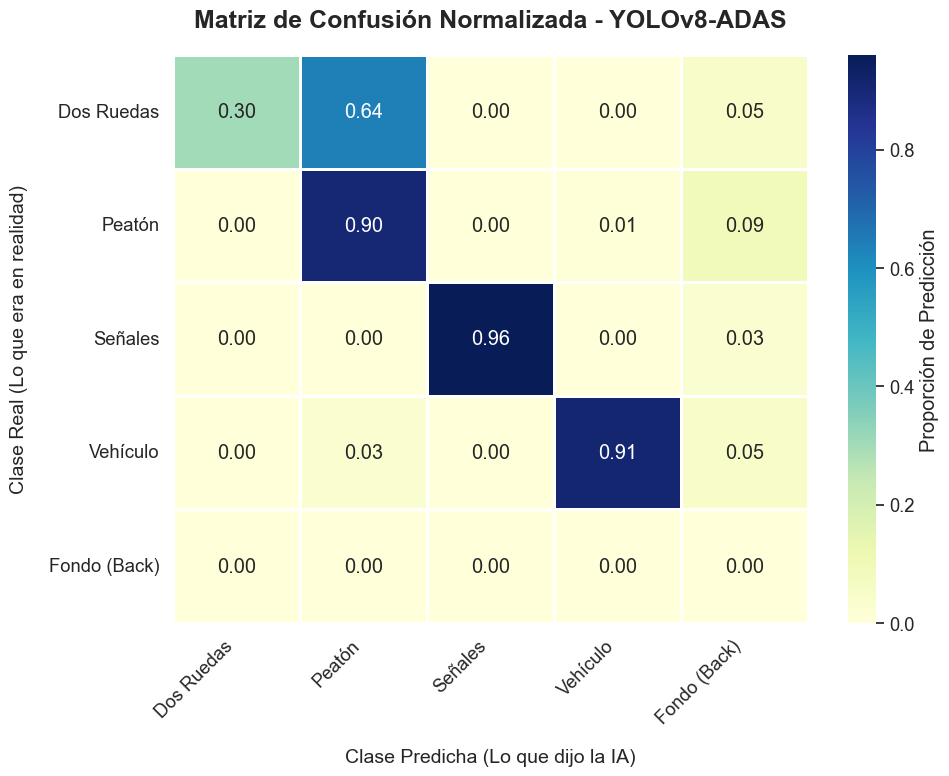

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. El orden EXACTO de tus clases según tu imagen original
clases = ['Dos Ruedas', 'Peatón', 'Señales', 'Vehículo', 'Fondo (Back)']

# 2. Los números EXACTOS extraídos de tu confusion_matrix_normalized.png
datos = np.array([
    [0.30, 0.64, 0.00, 0.00, 0.05], # Fila 1: Dos Ruedas
    [0.00, 0.90, 0.00, 0.01, 0.09], # Fila 2: Peatón
    [0.00, 0.00, 0.96, 0.00, 0.03], # Fila 3: Señales
    [0.00, 0.03, 0.00, 0.91, 0.05], # Fila 4: Vehículo
    [0.00, 0.00, 0.00, 0.00, 0.00]  # Fila 5: Fondo (Background FN)
])

# 3. Configurar el estilo visual
plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2) 

# 4. Crear el Mapa de Calor
ax = sns.heatmap(datos, annot=True, fmt=".2f", cmap="YlGnBu", 
                 xticklabels=clases, yticklabels=clases, 
                 cbar_kws={'label': 'Proporción de Predicción'},
                 linewidths=1, linecolor='white') 

# 5. Títulos y etiquetas profesionales
plt.title('Matriz de Confusión Normalizada - YOLOv8-ADAS', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Clase Predicha (Lo que dijo la IA)', fontsize=14, labelpad=15)
plt.ylabel('Clase Real (Lo que era en realidad)', fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# 6. Guardar y mostrar
plt.savefig('matriz_confusion_profesional_REAL.png', dpi=300, bbox_inches='tight')
plt.show()


Imagen 'yolo_curves_antonio.png' generada con éxito.


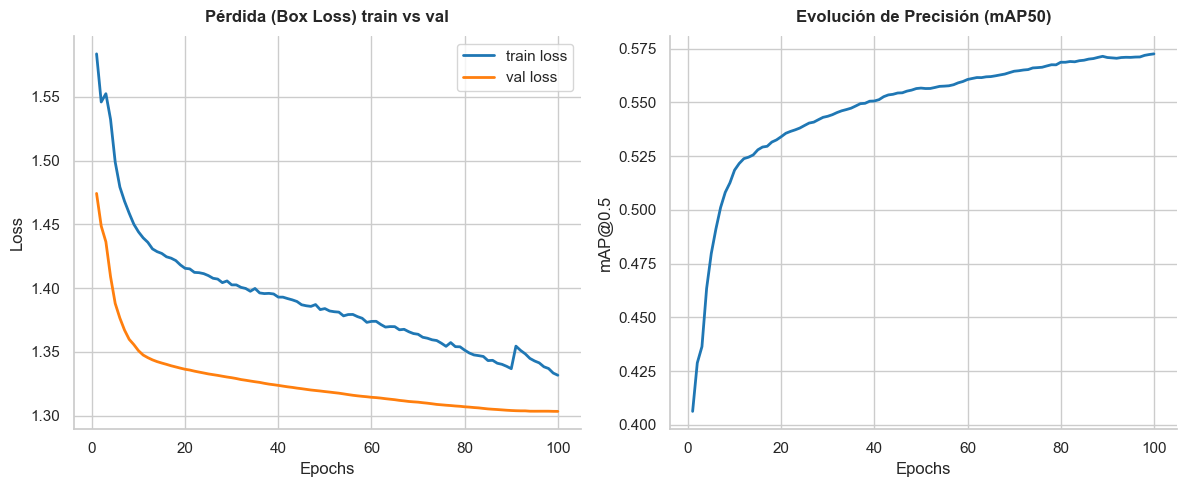

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos
df = pd.read_csv('C:\\Users\\Ender\\Documents\\Proyects_VScode\\Samsung-project\\models\\entrenamiento_script_estable\\results.csv') # Ajusta la ruta si es necesario
df.columns = df.columns.str.strip()

# 2. Configurar el estilo visual de tu compañero
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# 3. Crear el lienzo con 2 subgráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICA IZQUIERDA: Pérdida (Loss) ---
# Usamos tab:blue y tab:orange que son los colores exactos de su gráfica
ax1.plot(df['epoch'], df['train/box_loss'], label='train loss', color='tab:blue', linewidth=2)
ax1.plot(df['epoch'], df['val/box_loss'], label='val loss', color='tab:orange', linewidth=2)

ax1.set_title('Pérdida (Box Loss) train vs val', fontweight='bold', pad=10)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper right')

# --- GRÁFICA DERECHA: Precisión (mAP50) ---
ax2.plot(df['epoch'], df['metrics/mAP50(B)'], color='tab:blue', linewidth=2)

ax2.set_title('Evolución de Precisión (mAP50)', fontweight='bold', pad=10)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('mAP@0.5')

# Limpiar los bordes superior y derecho para imitar el estilo
sns.despine()

# Ajustar márgenes y guardar
plt.tight_layout()
plt.savefig('yolo_curves_antonio.png', dpi=300, bbox_inches='tight')
print("Imagen 'yolo_curves_antonio.png' generada con éxito.")
plt.show()

Imagen 'yolo_evaluation_antonio_REAL.png' generada con éxito.


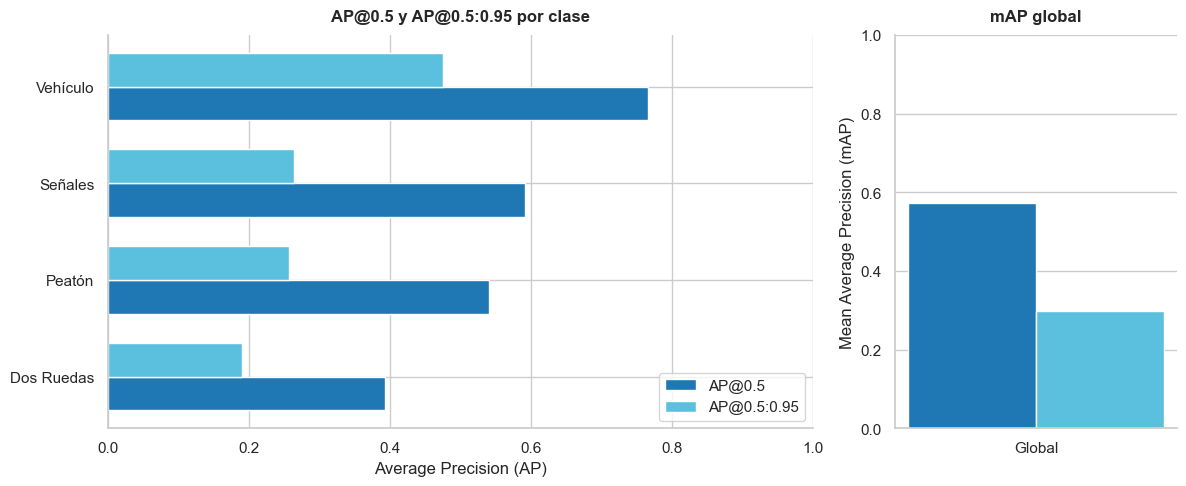

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tus datos EXACTOS de la consola (ordenados de mayor a menor AP@0.5)
clases = ['Vehículo', 'Señales', 'Peatón', 'Dos Ruedas']
ap50 = [0.766, 0.592, 0.541, 0.394] 
ap50_95 = [0.476, 0.264, 0.257, 0.190] 

# Datos globales directos de la consola
map_global_50 = 0.573
map_global_50_95 = 0.297

# 2. Configurar estilo visual calcado del de tu compañero
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# 3. Crear lienzo: La izquierda más ancha que la derecha
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2.5, 1]})

# --- GRÁFICA IZQUIERDA: Barras horizontales por clase ---
y = np.arange(len(clases))
alto = 0.35 # Grosor de las barras

# Colores idénticos a los de la gráfica de Rogelio
ax1.barh(y + alto/2, ap50, alto, label='AP@0.5', color='#1f77b4')
ax1.barh(y - alto/2, ap50_95, alto, label='AP@0.5:0.95', color='#5bc0de')

ax1.set_yticks(y)
ax1.set_yticklabels(clases)
ax1.invert_yaxis() # Para que la clase más alta quede arriba
ax1.set_xlabel('Average Precision (AP)')
ax1.set_title('AP@0.5 y AP@0.5:0.95 por clase', fontweight='bold', pad=10)
ax1.legend(loc='lower right')
ax1.set_xlim(0, 1.0) # Escala de 0 a 1

# --- GRÁFICA DERECHA: Barras verticales Globales ---
x = np.arange(1)
ancho = 0.4

ax2.bar(x - ancho/2, map_global_50, ancho, label='mAP@0.5', color='#1f77b4')
ax2.bar(x + ancho/2, map_global_50_95, ancho, label='mAP@0.5:0.95', color='#5bc0de')

ax2.set_xticks(x)
ax2.set_xticklabels(['Global'])
ax2.set_ylim(0, 1.0) # Escala de 0 a 1
ax2.set_ylabel('Mean Average Precision (mAP)')
ax2.set_title('mAP global', fontweight='bold', pad=10)
ax2.xaxis.grid(False) 

# Limpiar bordes
sns.despine()

# Ajustar y guardar
plt.tight_layout()
plt.savefig('yolo_evaluation_antonio_REAL.png', dpi=300, bbox_inches='tight')
print("Imagen 'yolo_evaluation_antonio_REAL.png' generada con éxito.")
plt.show()

¡Gráfica premium generada con éxito!


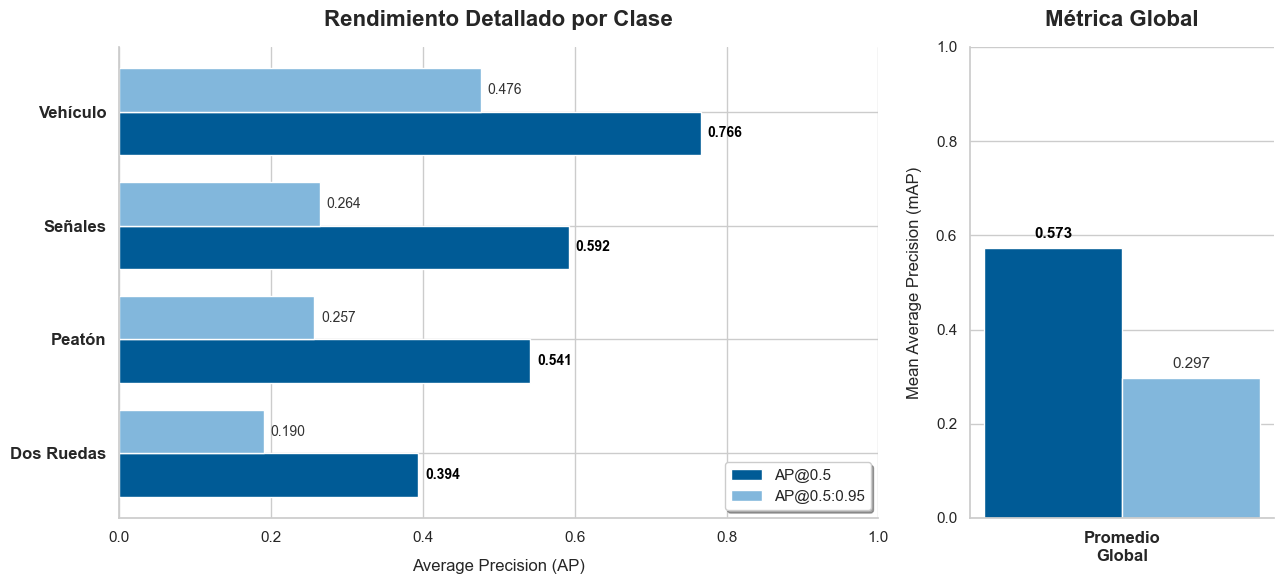

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tus datos EXACTOS
clases = ['Vehículo', 'Señales', 'Peatón', 'Dos Ruedas']
ap50 = [0.766, 0.592, 0.541, 0.394] 
ap50_95 = [0.476, 0.264, 0.257, 0.190] 

map_global_50 = 0.573
map_global_50_95 = 0.297

# 2. Configuración de estilo "Premium"
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Colores elegantes y profesionales
color_principal = '#005b96'   # Azul cobalto profundo
color_secundario = '#82b7dc'  # Azul acero suave

# 3. Crear el lienzo con proporciones armónicas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2.5, 1]})

# =======================================================
# GRÁFICA IZQUIERDA: Rendimiento por Clase
# =======================================================
y = np.arange(len(clases))
alto = 0.38 

# Dibujar barras con borde blanco para que luzcan más limpias
bar1 = ax1.barh(y + alto/2, ap50, alto, label='AP@0.5', color=color_principal, edgecolor='white')
bar2 = ax1.barh(y - alto/2, ap50_95, alto, label='AP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax1.set_yticks(y)
ax1.set_yticklabels(clases, fontweight='bold', fontsize=12) # Clases en negrita
ax1.invert_yaxis() 
ax1.set_xlabel('Average Precision (AP)', fontsize=12, labelpad=10)
ax1.set_title('Rendimiento Detallado por Clase', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlim(0, 1.0)
ax1.legend(loc='lower right', frameon=True, shadow=True)

# MAGIA: Añadir los números exactos (Data Labels) sobre las barras
ax1.bar_label(bar1, padding=5, fmt='%.3f', fontsize=10, color='black', fontweight='bold')
ax1.bar_label(bar2, padding=5, fmt='%.3f', fontsize=10, color='#333333')

# =======================================================
# GRÁFICA DERECHA: mAP Global
# =======================================================
x = np.arange(1)
ancho = 0.5

bar3 = ax2.bar(x - ancho/2, map_global_50, ancho, label='mAP@0.5', color=color_principal, edgecolor='white')
bar4 = ax2.bar(x + ancho/2, map_global_50_95, ancho, label='mAP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax2.set_xticks(x)
ax2.set_xticklabels(['Promedio\nGlobal'], fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Mean Average Precision (mAP)', fontsize=12, labelpad=10)
ax2.set_title('Métrica Global', fontsize=16, fontweight='bold', pad=15)
ax2.xaxis.grid(False) 

# MAGIA: Añadir los números exactos arriba de las barras globales
ax2.bar_label(bar3, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax2.bar_label(bar4, padding=5, fmt='%.3f', fontsize=11, color='#333333')

# =======================================================
# RETOQUES FINALES
# =======================================================
sns.despine() # Quitar bordes arriba y a la derecha
plt.tight_layout()

# Guardar imagen lista para Overleaf
plt.savefig('yolo_evaluation_antonio_PREMIUM.png', dpi=300, bbox_inches='tight')
print("¡Gráfica premium generada con éxito!")
plt.show()

¡Gráfica con nuevos colores generada con éxito!


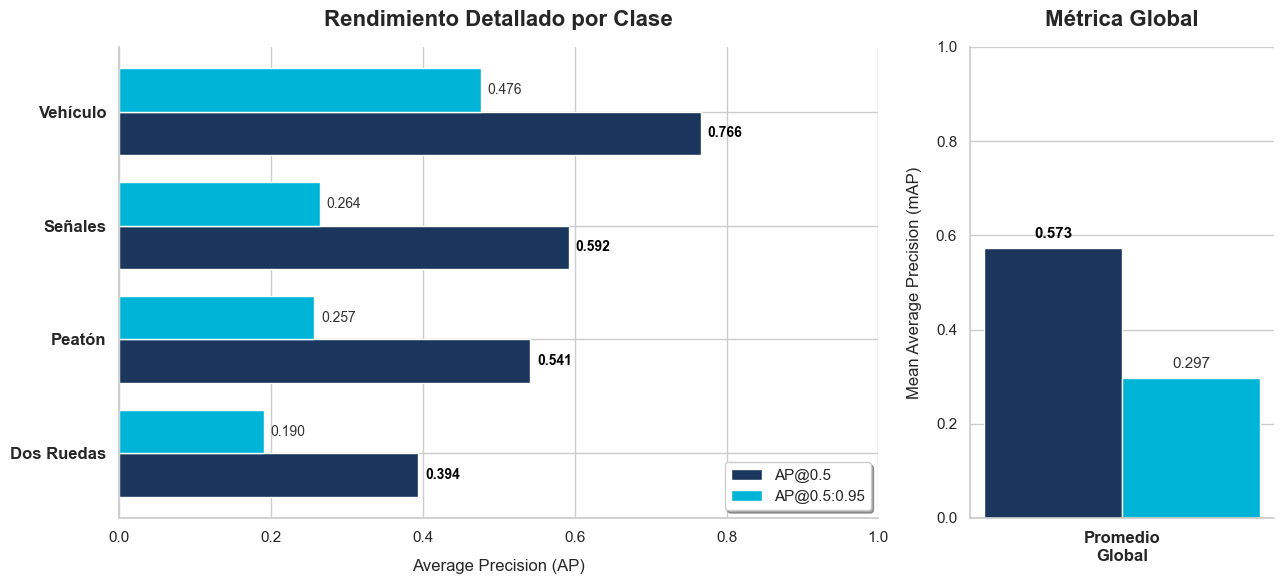

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tus datos EXACTOS
clases = ['Vehículo', 'Señales', 'Peatón', 'Dos Ruedas']
ap50 = [0.766, 0.592, 0.541, 0.394] 
ap50_95 = [0.476, 0.264, 0.257, 0.190] 

map_global_50 = 0.573
map_global_50_95 = 0.297

# 2. Configuración de estilo "Premium"
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# =======================================================
# AQUÍ CAMBIAS LOS COLORES (Formatos HEX)
# =======================================================
color_principal = '#1A365D'   # Azul Noche (Elegante y formal)
color_secundario = '#00B4D8'  # Turquesa Vibrante (Resalta mucho)

# Otras paletas que puedes probar copiando y pegando:
# color_principal = '#2B2D42' (Gris Oscuro)  | color_secundario = '#EF233C' (Rojo Vivo)
# color_principal = '#134611' (Verde Bosque) | color_secundario = '#3E8914' (Verde Claro)
# =======================================================

# 3. Crear el lienzo con proporciones armónicas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2.5, 1]})

# =======================================================
# GRÁFICA IZQUIERDA: Rendimiento por Clase
# =======================================================
y = np.arange(len(clases))
alto = 0.38 

bar1 = ax1.barh(y + alto/2, ap50, alto, label='AP@0.5', color=color_principal, edgecolor='white')
bar2 = ax1.barh(y - alto/2, ap50_95, alto, label='AP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax1.set_yticks(y)
ax1.set_yticklabels(clases, fontweight='bold', fontsize=12)
ax1.invert_yaxis() 
ax1.set_xlabel('Average Precision (AP)', fontsize=12, labelpad=10)
ax1.set_title('Rendimiento Detallado por Clase', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlim(0, 1.0)
ax1.legend(loc='lower right', frameon=True, shadow=True)

# Data Labels (Números)
ax1.bar_label(bar1, padding=5, fmt='%.3f', fontsize=10, color='black', fontweight='bold')
ax1.bar_label(bar2, padding=5, fmt='%.3f', fontsize=10, color='#333333')

# =======================================================
# GRÁFICA DERECHA: mAP Global
# =======================================================
x = np.arange(1)
ancho = 0.5

bar3 = ax2.bar(x - ancho/2, map_global_50, ancho, label='mAP@0.5', color=color_principal, edgecolor='white')
bar4 = ax2.bar(x + ancho/2, map_global_50_95, ancho, label='mAP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax2.set_xticks(x)
ax2.set_xticklabels(['Promedio\nGlobal'], fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Mean Average Precision (mAP)', fontsize=12, labelpad=10)
ax2.set_title('Métrica Global', fontsize=16, fontweight='bold', pad=15)
ax2.xaxis.grid(False) 

# Data Labels
ax2.bar_label(bar3, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax2.bar_label(bar4, padding=5, fmt='%.3f', fontsize=11, color='#333333')

# =======================================================
# RETOQUES FINALES
# =======================================================
sns.despine() 
plt.tight_layout()

# Guardar imagen
plt.savefig('yolo_evaluation_antonio_NUEVOS_COLORES.png', dpi=300, bbox_inches='tight')
print("¡Gráfica con nuevos colores generada con éxito!")
plt.show()

In [4]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Cargar y limpiar los datos de tu results.csv
ruta_csv = '../models/entrenamiento_script_estable/results.csv' 
df = pd.read_csv(ruta_csv)
df.columns = df.columns.str.strip()

# 2. Crear el lienzo con 1 fila y 2 columnas
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("Análisis de Pérdida (Box Loss)", 
                                    "Evolución de la Precisión Media (mAP50)"))

# ============================================================
# LADO IZQUIERDO: Evolución del Error
# ============================================================
fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['train/box_loss'], 
               name="Entrenamiento", line=dict(color='#E63946', width=3)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['val/box_loss'], 
               name="Validación", line=dict(color='#F4A261', width=3, dash='dot')),
    row=1, col=1
)

# ============================================================
# LADO DERECHO: Evolución de la Precisión
# ============================================================
fig.add_trace(
    go.Scatter(x=df['epoch'], y=df['metrics/mAP50(B)'], 
               name="Precisión (mAP50)", line=dict(color='#7209B7', width=4)),
    row=1, col=2
)

# ============================================================
# DISEÑO GLOBAL Y EXPORTACIÓN
# ============================================================
fig.update_layout(
    template="plotly_white", 
    hovermode="x unified",
    font=dict(size=14),
    width=1200,  # Fija el ancho para que no se estire
    height=550,  # Fija el alto para una proporción perfecta
    # Ponemos una sola leyenda central abajo para que ambas gráficas respiren
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.15,
        xanchor="center", x=0.5,
        bgcolor="rgba(255, 255, 255, 0.85)",
        bordercolor="Black", borderwidth=1
    )
)

# Nombrar los ejes X e Y de cada lado
fig.update_xaxes(title_text="Épocas de Entrenamiento", row=1, col=1)
fig.update_xaxes(title_text="Épocas de Entrenamiento", row=1, col=2)
fig.update_yaxes(title_text="Pérdida (Box Loss)", row=1, col=1)
fig.update_yaxes(title_text="Precisión (mAP50)", row=1, col=2)

print("Mostrando Gráfica Combinada...")
fig.show()

# Opcional: Para guardar directamente como imagen desde código (Requiere pip install -U kaleido)
# fig.write_image("yolo_curves_antonio_combinada.png", scale=2)

Mostrando Gráfica Combinada...


¡Gráfica 100% de barras verticales generada con éxito!


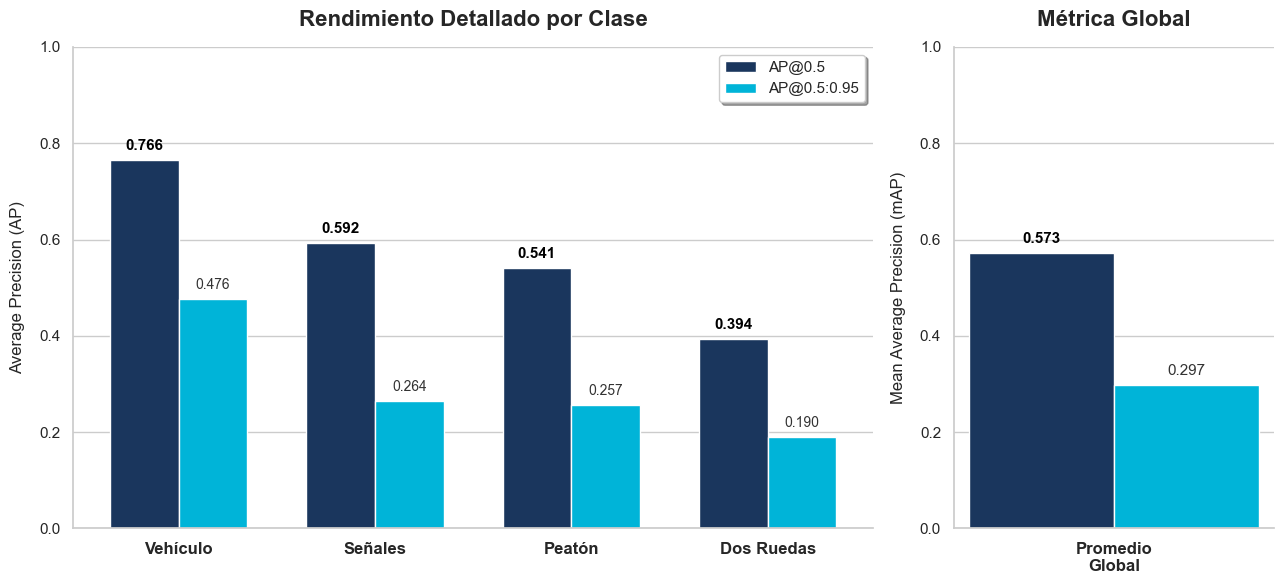

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tus datos EXACTOS
clases = ['Vehículo', 'Señales', 'Peatón', 'Dos Ruedas']
ap50 = [0.766, 0.592, 0.541, 0.394] 
ap50_95 = [0.476, 0.264, 0.257, 0.190] 

map_global_50 = 0.573
map_global_50_95 = 0.297

# 2. Configuración de estilo "Premium"
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# =======================================================
# COLORES PREMIUM
# =======================================================
color_principal = '#1A365D'   # Azul Noche 
color_secundario = '#00B4D8'  # Turquesa Vibrante 

# 3. Crear el lienzo 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2.5, 1]})

# =======================================================
# GRÁFICA IZQUIERDA: Rendimiento por Clase (VERTICAL)
# =======================================================
x_clases = np.arange(len(clases))
ancho = 0.35 # Hacemos las barras un poco más delgadas para que luzcan elegantes

# Usamos ax1.bar en lugar de ax1.barh
bar1 = ax1.bar(x_clases - ancho/2, ap50, ancho, label='AP@0.5', color=color_principal, edgecolor='white')
bar2 = ax1.bar(x_clases + ancho/2, ap50_95, ancho, label='AP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes X e Y
ax1.set_xticks(x_clases)
ax1.set_xticklabels(clases, fontweight='bold', fontsize=12)
ax1.set_ylim(0, 1.0) # El límite ahora es el eje Y (de 0 a 100%)
ax1.set_ylabel('Average Precision (AP)', fontsize=12, labelpad=10)
ax1.set_title('Rendimiento Detallado por Clase', fontsize=16, fontweight='bold', pad=15)

# Movemos la leyenda arriba a la derecha
ax1.legend(loc='upper right', frameon=True, shadow=True)

# Data Labels (Números sobre las barras)
ax1.bar_label(bar1, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax1.bar_label(bar2, padding=5, fmt='%.3f', fontsize=10, color='#333333')

# Quitamos las líneas verticales de fondo para mayor limpieza
ax1.xaxis.grid(False) 

# =======================================================
# GRÁFICA DERECHA: mAP Global (VERTICAL)
# =======================================================
x_global = np.arange(1)

bar3 = ax2.bar(x_global - ancho/2, map_global_50, ancho, label='mAP@0.5', color=color_principal, edgecolor='white')
bar4 = ax2.bar(x_global + ancho/2, map_global_50_95, ancho, label='mAP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax2.set_xticks(x_global)
ax2.set_xticklabels(['Promedio\nGlobal'], fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Mean Average Precision (mAP)', fontsize=12, labelpad=10)
ax2.set_title('Métrica Global', fontsize=16, fontweight='bold', pad=15)
ax2.xaxis.grid(False) 

# Data Labels
ax2.bar_label(bar3, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax2.bar_label(bar4, padding=5, fmt='%.3f', fontsize=11, color='#333333')

# =======================================================
# RETOQUES FINALES
# =======================================================
sns.despine() # Quita la caja exterior
plt.tight_layout()

# Guardar imagen lista para Overleaf
plt.savefig('yolo_evaluation_antonio_VERTICAL.png', dpi=300, bbox_inches='tight')
print("¡Gráfica 100% de barras verticales generada con éxito!")
plt.show()

¡Gráfica con nuevos colores generada con éxito!


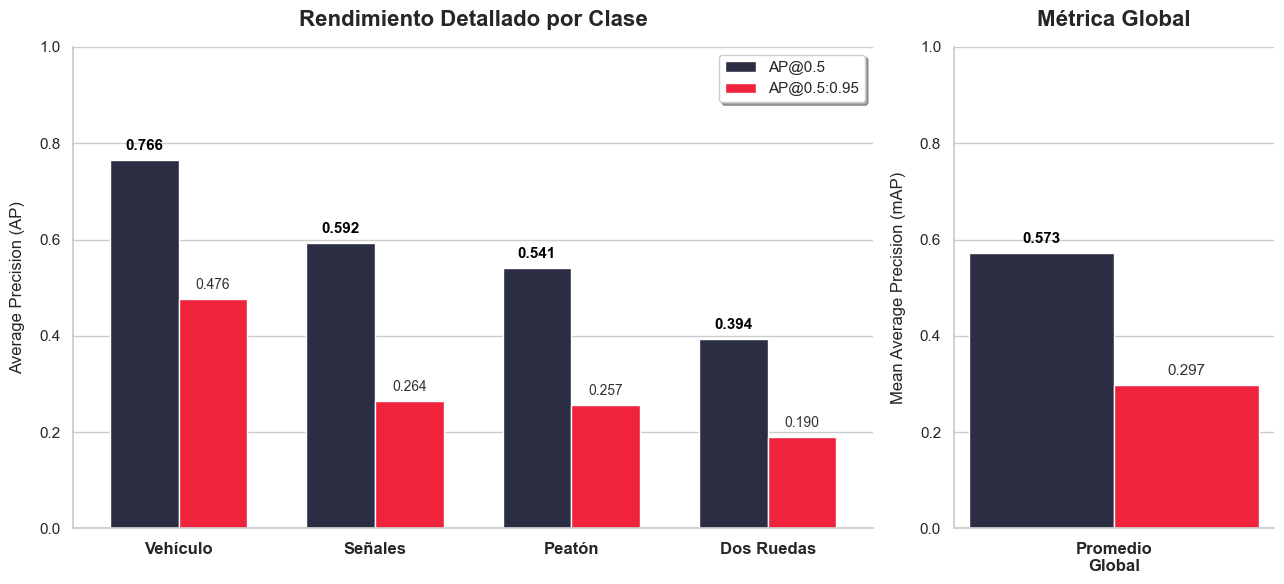

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tus datos EXACTOS
clases = ['Vehículo', 'Señales', 'Peatón', 'Dos Ruedas']
ap50 = [0.766, 0.592, 0.541, 0.394] 
ap50_95 = [0.476, 0.264, 0.257, 0.190] 

map_global_50 = 0.573
map_global_50_95 = 0.297

# 2. Configuración de estilo "Premium"
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# =======================================================
# NUEVA PALETA DE COLORES (Alto Contraste)
# =======================================================
color_principal = '#2B2D42'   # Gris Pizarra Oscuro (Elegante y técnico)
color_secundario = '#EF233C'  # Rojo Carmesí Vibrante (Excelente contraste)

# OTRAS OPCIONES LISTAS PARA USAR (Solo quita el # para activarlas):
# Opción "Esmeralda" (Ideal para denotar precisión/éxito)
# color_principal = '#0A5C36' 
# color_secundario = '#20C997' 

# Opción "Cyber" (Muy moderno)
# color_principal = '#3A0CA3' # Morado profundo
# color_secundario = '#F72585' # Rosa neón
# =======================================================

# 3. Crear el lienzo 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2.5, 1]})

# =======================================================
# GRÁFICA IZQUIERDA: Rendimiento por Clase (VERTICAL)
# =======================================================
x_clases = np.arange(len(clases))
ancho = 0.35 

bar1 = ax1.bar(x_clases - ancho/2, ap50, ancho, label='AP@0.5', color=color_principal, edgecolor='white')
bar2 = ax1.bar(x_clases + ancho/2, ap50_95, ancho, label='AP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes X e Y
ax1.set_xticks(x_clases)
ax1.set_xticklabels(clases, fontweight='bold', fontsize=12)
ax1.set_ylim(0, 1.0) 
ax1.set_ylabel('Average Precision (AP)', fontsize=12, labelpad=10)
ax1.set_title('Rendimiento Detallado por Clase', fontsize=16, fontweight='bold', pad=15)

# Leyenda
ax1.legend(loc='upper right', frameon=True, shadow=True)

# Data Labels (Números sobre las barras)
ax1.bar_label(bar1, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax1.bar_label(bar2, padding=5, fmt='%.3f', fontsize=10, color='#333333')

# Quitamos las líneas verticales de fondo 
ax1.xaxis.grid(False) 

# =======================================================
# GRÁFICA DERECHA: mAP Global (VERTICAL)
# =======================================================
x_global = np.arange(1)

bar3 = ax2.bar(x_global - ancho/2, map_global_50, ancho, label='mAP@0.5', color=color_principal, edgecolor='white')
bar4 = ax2.bar(x_global + ancho/2, map_global_50_95, ancho, label='mAP@0.5:0.95', color=color_secundario, edgecolor='white')

# Configuración de ejes
ax2.set_xticks(x_global)
ax2.set_xticklabels(['Promedio\nGlobal'], fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Mean Average Precision (mAP)', fontsize=12, labelpad=10)
ax2.set_title('Métrica Global', fontsize=16, fontweight='bold', pad=15)
ax2.xaxis.grid(False) 

# Data Labels
ax2.bar_label(bar3, padding=5, fmt='%.3f', fontsize=11, color='black', fontweight='bold')
ax2.bar_label(bar4, padding=5, fmt='%.3f', fontsize=11, color='#333333')

# =======================================================
# RETOQUES FINALES
# =======================================================
sns.despine() 
plt.tight_layout()

# Guardar imagen lista para Overleaf
plt.savefig('yolo_evaluation_antonio_VERTICAL.png', dpi=300, bbox_inches='tight')
print("¡Gráfica con nuevos colores generada con éxito!")
plt.show()

1. Cargando modelo y ejecutando validación (esto tomará unos segundos)...
Ultralytics 8.4.33  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)


Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 711.3272.2 MB/s, size: 79.2 KB)
val: Scanning C:\Users\Ender\Documents\Proyects_VScode\Samsung-project\data\enhanced\labels\val.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 10.3it/s 1:00<0.1ss
                   all      10000     185563      0.705      0.507      0.573      0.297
Speed: 0.6ms preprocess, 1.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\Ender\Documents\Proyects_VScode\Samsung-project\notebooks\runs\detect\val4
2. Extrayendo y procesando matemáticas...
3. Generando imagen con estilo Premium...
¡ÉXITO! Imagen 'matriz_confusion_premium_AUTO.png' generada y lista para LaTeX.


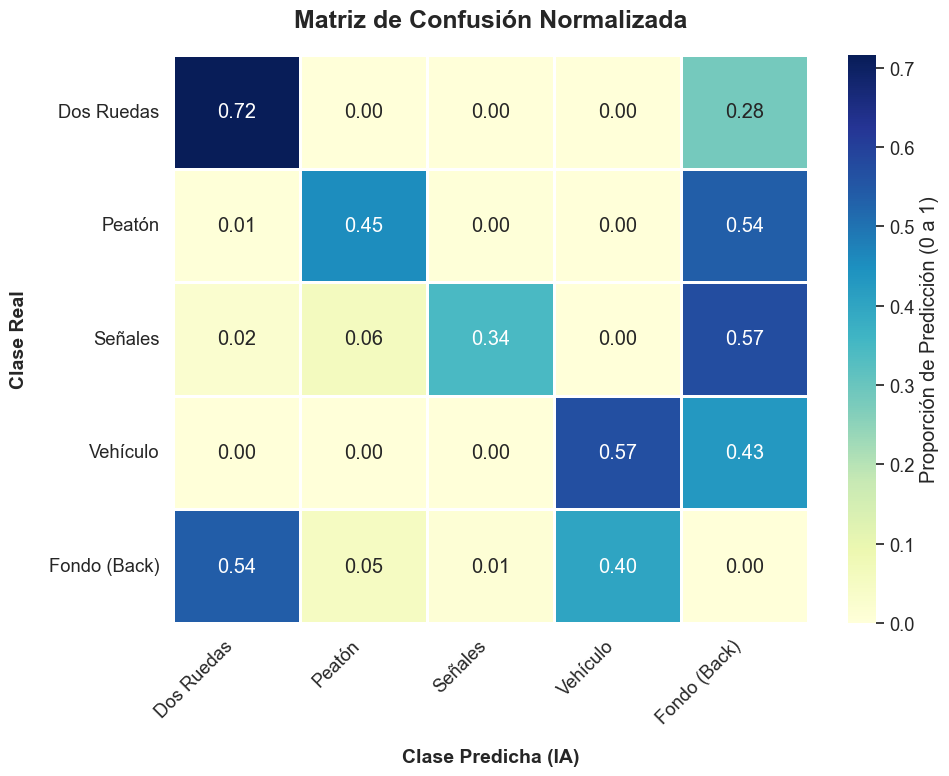

In [9]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Cargando modelo y ejecutando validación (esto tomará unos segundos)...")
# Cargar tu modelo entrenado
model = YOLO('../models/entrenamiento_script_estable/weights/best.pt')

# Ejecutar la validación silenciosamente
metrics = model.val(verbose=False)

print("2. Extrayendo y procesando matemáticas...")
# Extraer la matriz de confusión bruta (conteos exactos de objetos)
matriz_bruta = metrics.confusion_matrix.matrix

# Normalizar la matriz (convertir los conteos a porcentajes de 0.00 a 1.00)
# Dividimos cada fila (Clase Real) entre el total de objetos de esa clase
suma_por_fila = matriz_bruta.sum(axis=0, keepdims=True) # YOLO guarda los "True" en las columnas
matriz_normalizada = matriz_bruta / (suma_por_fila + 1e-6) # 1e-6 evita división por cero
matriz_normalizada = matriz_normalizada.T # Transponemos para que cuadre visualmente (Filas=Real, Cols=Pred)

# 3. Nombres de las clases (YOLO agrega 'Fondo' al final automáticamente)
# Asegúrate de que este sea el orden en el que tu modelo entrenó sus clases
clases = ['Dos Ruedas', 'Peatón', 'Señales', 'Vehículo', 'Fondo (Back)']

print("3. Generando imagen con estilo Premium...")
# Configurar el estilo visual
plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2) 

# Crear el Mapa de Calor con la paleta de contraste profesional (YlGnBu)
ax = sns.heatmap(matriz_normalizada, annot=True, fmt=".2f", cmap="YlGnBu", 
                 xticklabels=clases, yticklabels=clases, 
                 cbar_kws={'label': 'Proporción de Predicción (0 a 1)'},
                 linewidths=1, linecolor='white') 

# Títulos y etiquetas profesionales
plt.title('Matriz de Confusión Normalizada', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Clase Predicha (IA)', fontsize=14, labelpad=15, fontweight='bold')
plt.ylabel('Clase Real', fontsize=14, labelpad=15, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# 4. Guardar imagen directamente para Overleaf
plt.savefig('matriz_confusion_premium_AUTO.png', dpi=300, bbox_inches='tight')
print("¡ÉXITO! Imagen 'matriz_confusion_premium_AUTO.png' generada y lista para LaTeX.")
plt.show()